# Notebook 3 : Grad-CAM (CPU Optimisé)

**Couche cible :** `out_relu` (dernière activation de MobileNetV2)

| Modèle | Couche Grad-CAM |
|---|---|
| EfficientNet-B4 | `top_activation` |
| **MobileNetV2** | **`out_relu`** |

---

## Imports & Chargement du Modèle

In [1]:
import os, warnings, json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import cv2
from PIL import Image
import tensorflow as tf
from tensorflow import keras

warnings.filterwarnings('ignore')

MODELS_DIR    = r'..\models'
RESULTS_DIR   = r'..\results'
PROCESSED_DIR = r'..\data\processed'
os.makedirs(os.path.join(RESULTS_DIR, 'gradcam'), exist_ok=True)

# Lire IMG_SIZE depuis config
with open(os.path.join(PROCESSED_DIR, 'config.json')) as f:
    cfg = json.load(f)
IMG_SIZE = cfg['IMG_SIZE']

MODEL_PATH = os.path.join(MODELS_DIR, 'deepshield_best.keras')
model = keras.models.load_model(MODEL_PATH)
print(f'Modèle chargé : {MODEL_PATH}')
print(f'   IMG_SIZE : {IMG_SIZE}')
print(f'   Input    : {model.input_shape}')

Modèle chargé : ..\models\deepshield_best.keras
   IMG_SIZE : 128
   Input    : (None, 128, 128, 3)


---
## Identifier la Couche Cible MobileNetV2

In [2]:
# Trouver le sous-modèle MobileNetV2
mobilenet_model = None
for layer in model.layers:
    if hasattr(layer, 'layers'):
        mobilenet_model = layer
        print(f'Sous-modèle trouvé : {layer.name}')
        break

print('\n10 dernières couches :')
for l in mobilenet_model.layers[-10:]:
    print(f'  {l.name:55s}  {type(l).__name__}')

# Couche cible pour MobileNetV2
GRADCAM_LAYER = 'out_relu'

# Vérification
layer_names = [l.name for l in mobilenet_model.layers]
if GRADCAM_LAYER not in layer_names:
    # Fallback automatique : dernière activation
    candidates = [l.name for l in mobilenet_model.layers
                  if 'relu' in l.name or 'activation' in l.name]
    GRADCAM_LAYER = candidates[-1]
    print(f' Fallback couche : {GRADCAM_LAYER}')
else:
    print(f'\n Couche cible Grad-CAM : {GRADCAM_LAYER}')

Sous-modèle trouvé : mobilenetv2_1.00_128

10 dernières couches :
  block_16_expand_BN                                       BatchNormalization
  block_16_expand_relu                                     ReLU
  block_16_depthwise                                       DepthwiseConv2D
  block_16_depthwise_BN                                    BatchNormalization
  block_16_depthwise_relu                                  ReLU
  block_16_project                                         Conv2D
  block_16_project_BN                                      BatchNormalization
  Conv_1                                                   Conv2D
  Conv_1_bn                                                BatchNormalization
  out_relu                                                 ReLU

 Couche cible Grad-CAM : out_relu


---
## Fonctions Grad-CAM

In [3]:
def get_gradcam_heatmap(model, img_array, layer_name=GRADCAM_LAYER):
    """
    Calcule la heatmap Grad-CAM pour une image.
    img_array : (1, IMG_SIZE, IMG_SIZE, 3) float32 [0,1]
    """
    # Trouver le sous-modèle MobileNetV2
    mobilenet_model = None
    for layer in model.layers:
        if hasattr(layer, 'layers'):
            mobilenet_model = layer
            break

    if mobilenet_model is None:
        raise ValueError('Sous-modèle MobileNetV2 introuvable.')

    # Fallback si couche introuvable
    layer_names = [l.name for l in mobilenet_model.layers]
    if layer_name not in layer_names:
        candidates = [l.name for l in mobilenet_model.layers
                      if 'relu' in l.name or 'activation' in l.name]
        layer_name = candidates[-1]

    # Modèle intermédiaire depuis les inputs MobileNetV2
    grad_model = keras.Model(
        inputs=mobilenet_model.input,
        outputs=[
            mobilenet_model.get_layer(layer_name).output,
            mobilenet_model.output
        ]
    )

    with tf.GradientTape() as tape:
        img_tensor          = tf.cast(img_array, tf.float32)
        conv_outputs, preds = grad_model(img_tensor, training=False)
        loss                = preds[:, 0]

    grads        = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap      = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap      = tf.squeeze(heatmap)
    heatmap      = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()


def overlay_gradcam(img_array, heatmap, alpha=0.4):
    """Superpose la heatmap sur l'image. img_array : (H,W,3) float32 [0,1]"""
    h_resized = cv2.resize(heatmap, (img_array.shape[1], img_array.shape[0]))
    h_colored = cm.jet(h_resized)[:, :, :3]
    result    = (1 - alpha) * img_array.astype('float32') + alpha * h_colored
    return np.clip(result, 0, 1)


print(' Fonctions Grad-CAM définies.')

 Fonctions Grad-CAM définies.


---
## Test Grad-CAM sur Exemples (REAL + FAKE)

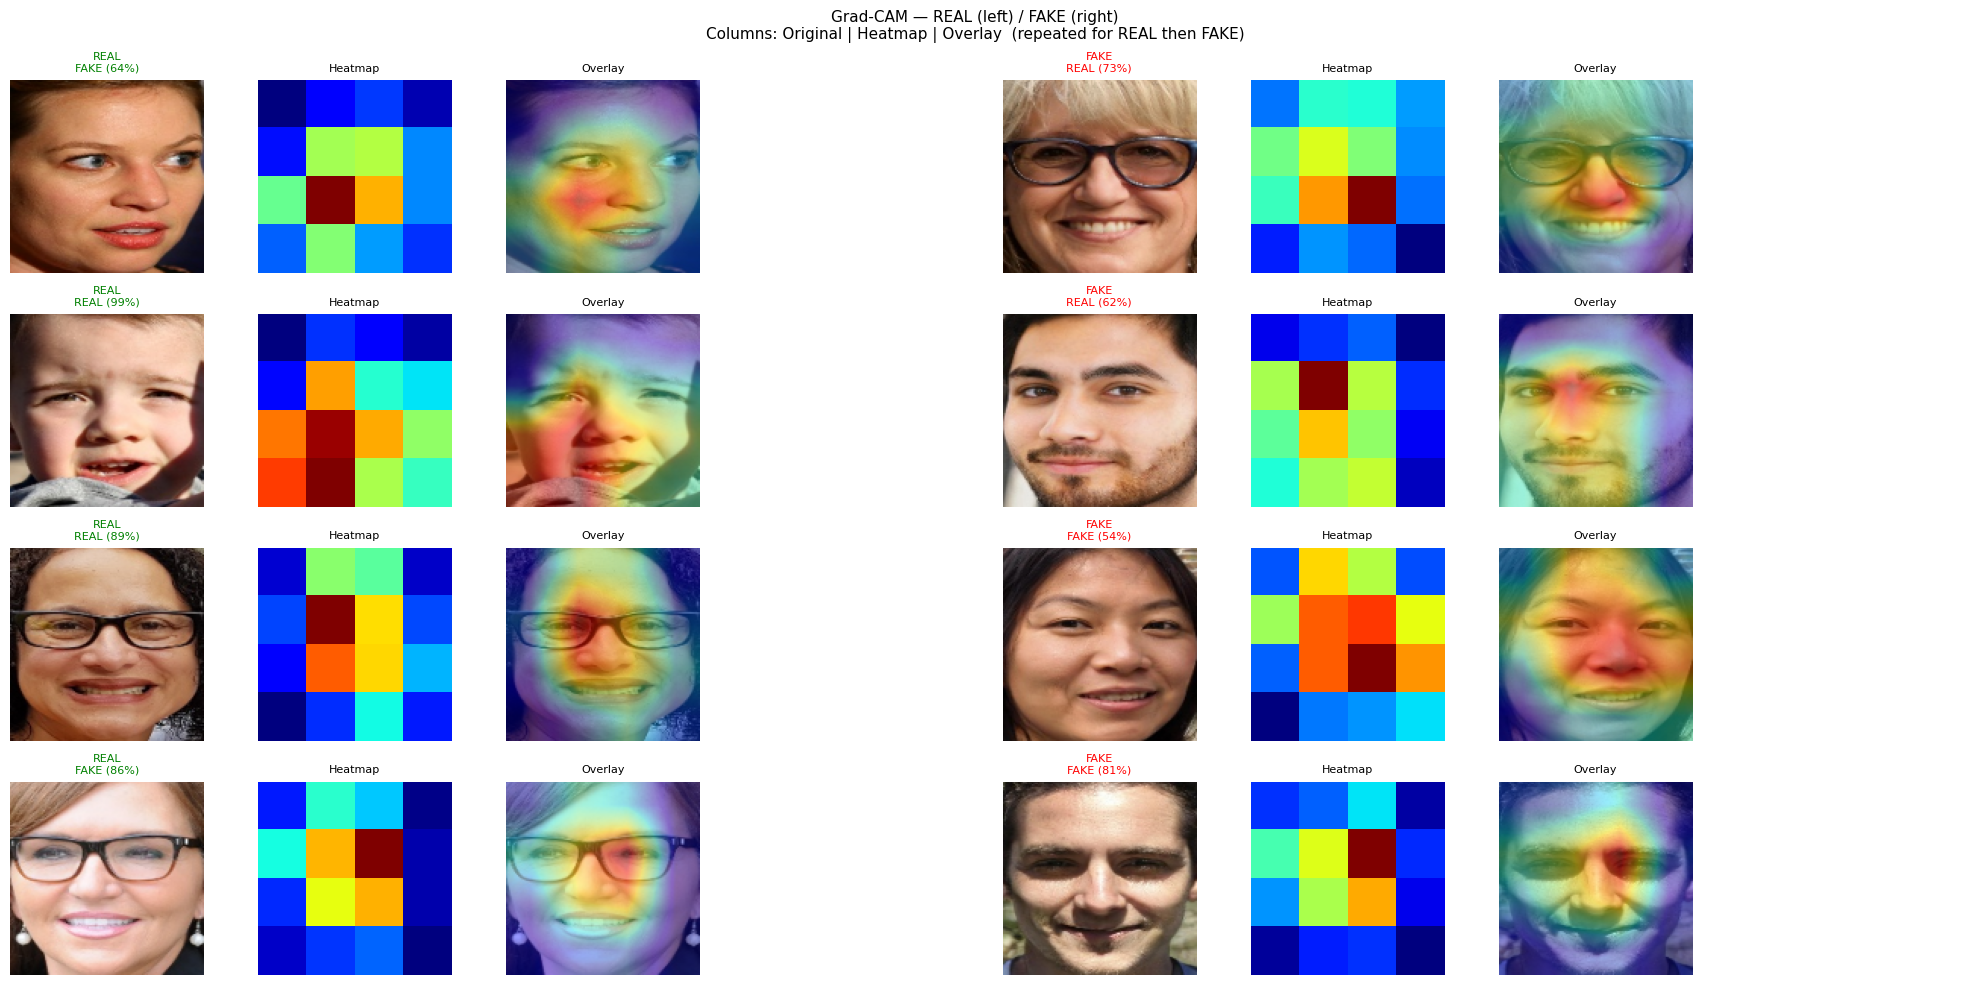

Grad-CAM sauvegardé dans results/gradcam/


In [4]:
X_test = np.load(os.path.join(PROCESSED_DIR, 'X_test.npy'))
y_test = np.load(os.path.join(PROCESSED_DIR, 'y_test.npy'))

real_idx = np.where(y_test == 0)[0][:4]
fake_idx = np.where(y_test == 1)[0][:4]

fig, axes = plt.subplots(4, 8, figsize=(20, 10))
fig.suptitle('Grad-CAM — REAL (left) / FAKE (right)\n'
             'Columns: Original | Heatmap | Overlay  (repeated for REAL then FAKE)',
             fontsize=11)

def plot_gradcam_row(ax_orig, ax_heat, ax_over, img, label_str, color):
    img_input  = np.expand_dims(img, axis=0)
    pred       = model.predict(img_input, verbose=0)[0][0]
    heatmap    = get_gradcam_heatmap(model, img_input)
    overlay    = overlay_gradcam(img, heatmap)
    pred_label = 'FAKE' if pred >= 0.5 else 'REAL'
    conf       = pred if pred >= 0.5 else 1 - pred

    ax_orig.imshow(img)
    ax_orig.set_title(f'{label_str}\n{pred_label} ({conf:.0%})', color=color, fontsize=8)
    ax_orig.axis('off')
    ax_heat.imshow(heatmap, cmap='jet')
    ax_heat.set_title('Heatmap', fontsize=8); ax_heat.axis('off')
    ax_over.imshow(overlay)
    ax_over.set_title('Overlay', fontsize=8); ax_over.axis('off')

for row, idx in enumerate(real_idx):
    plot_gradcam_row(axes[row][0], axes[row][1], axes[row][2],
                    X_test[idx], 'REAL', 'green')

for row, idx in enumerate(fake_idx):
    plot_gradcam_row(axes[row][4], axes[row][5], axes[row][6],
                    X_test[idx], 'FAKE', 'red')

for row in range(4):
    axes[row][3].axis('off'); axes[row][7].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'gradcam', 'gradcam_examples.png'), dpi=120)
plt.show()
print('Grad-CAM sauvegardé dans results/gradcam/')

---
## Analyse Détaillée sur 1 Image Fake

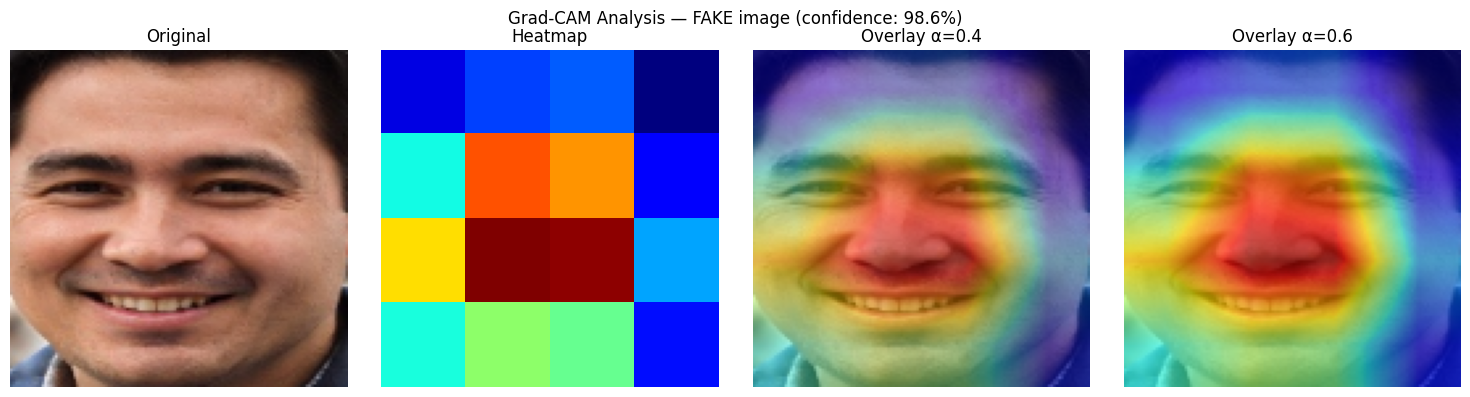

 Analyse détaillée sauvegardée. Score FAKE : 0.9861


In [5]:
fake_indices = np.where(y_test == 1)[0]
fake_preds   = model.predict(X_test[fake_indices], batch_size=16, verbose=0).flatten()
best_idx     = fake_indices[np.argmax(fake_preds)]

img        = X_test[best_idx]
img_input  = np.expand_dims(img, axis=0)
pred_score = model.predict(img_input, verbose=0)[0][0]
heatmap    = get_gradcam_heatmap(model, img_input)

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
fig.suptitle(f'Grad-CAM Analysis — FAKE image (confidence: {pred_score:.1%})', fontsize=12)

axes[0].imshow(img);                        axes[0].set_title('Original');          axes[0].axis('off')
axes[1].imshow(heatmap, cmap='jet');        axes[1].set_title('Heatmap');            axes[1].axis('off')
axes[2].imshow(overlay_gradcam(img, heatmap, alpha=0.4)); axes[2].set_title('Overlay α=0.4'); axes[2].axis('off')
axes[3].imshow(overlay_gradcam(img, heatmap, alpha=0.6)); axes[3].set_title('Overlay α=0.6'); axes[3].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, 'gradcam', 'gradcam_detail_fake.png'), dpi=120)
plt.show()
print(f' Analyse détaillée sauvegardée. Score FAKE : {pred_score:.4f}')

---
##  Générer gradcam_utils.py

Exporte les fonctions Grad-CAM dans `gradcam_utils.py` pour `app.py`.

In [7]:
code = '''
import numpy as np
import cv2
import matplotlib.cm as cm
import tensorflow as tf
from tensorflow import keras

GRADCAM_LAYER = "out_relu"  # MobileNetV2

def get_gradcam_heatmap(model, img_array, layer_name=GRADCAM_LAYER):
    mobilenet_model = None
    for layer in model.layers:
        if hasattr(layer, "layers"):
            mobilenet_model = layer
            break
    if mobilenet_model is None:
        raise ValueError("Sous-modèle MobileNetV2 introuvable.")
    layer_names = [l.name for l in mobilenet_model.layers]
    if layer_name not in layer_names:
        candidates = [l.name for l in mobilenet_model.layers
                      if "relu" in l.name or "activation" in l.name]
        layer_name = candidates[-1]
    grad_model = keras.Model(
        inputs=mobilenet_model.input,
        outputs=[mobilenet_model.get_layer(layer_name).output,
                 mobilenet_model.output]
    )
    with tf.GradientTape() as tape:
        img_tensor          = tf.cast(img_array, tf.float32)
        conv_outputs, preds = grad_model(img_tensor, training=False)
        loss                = preds[:, 0]
    grads        = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap      = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap      = tf.squeeze(heatmap)
    heatmap      = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

def overlay_gradcam(img_array, heatmap, alpha=0.4):
    h_resized = cv2.resize(heatmap, (img_array.shape[1], img_array.shape[0]))
    h_colored = cm.jet(h_resized)[:, :, :3]
    result    = (1 - alpha) * img_array.astype("float32") + alpha * h_colored
    return np.clip(result, 0, 1)
'''

utils_path = r'..\gradcam_utils.py'
with open(utils_path, 'w', encoding='utf-8') as f:
    f.write(code)

print(f'gradcam_utils.py généré : {os.path.abspath(utils_path)}')
print('\n' + '='*50)
print(' Notebook 3 terminé !')
print('   → Prochain : python app.py')
print('='*50)

gradcam_utils.py généré : c:\Users\nasri\OneDrive\Desktop\Projects\DeepShield Detect\gradcam_utils.py

 Notebook 3 terminé !
   → Prochain : python app.py
